# Customer Segmentation Using Unsupervised Learning

---

## 1. Problem Statement and Objective

Retailers today collect large amounts of customer data, but without proper analy,sis this data does not translate into actionable business decisions. The **Mall Customers dataset** contains basic demographic and spending information for 200 shopping mall customers, including their annual income and a mall-assigned spending score.

**Problem:** The mall currently treats all customers as a single homogeneous group when planning marketing campaigns. This one-size-fits-all approach is inefficient, as high-value customers are not specifically nurtured, and low-engagement customers are not specifically targeted for re-engagement.

**Objective:** The goal of this task is to:
1. Explore and understand customer spending habits and demographics through EDA.
2. Apply **K-Means Clustering** (unsupervised learning) to segment customers into meaningful groups based on their spending habits and income.
3. Use **PCA** and **t-SNE** to visualize the resulting clusters in reduced dimensions.
4. Translate each cluster into a customer **segment persona** and propose a **tailored marketing strategy** for each.

**Skills demonstrated:** Unsupervised learning (K-Means), dimensionality reduction (PCA, t-SNE), customer segmentation, and data-driven strategy development.


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42


## 2. Dataset Description and Loading

The **Mall Customers dataset** contains the following columns:

| Column | Description |
|---|---|
| `CustomerID` | Unique identifier for each customer |
| `Gender` | Male / Female |
| `Age` | Customer's age in years |
| `Education` | Highest education level attained |
| `Marital Status` | Married / Single / Divorced / Unknown |
| `Annual Income (k$)` | Annual income of the customer, in thousands of dollars |
| `Spending Score (1-100)` | A score (1-100) assigned by the mall based on customer behavior and spending nature |

The two variables of primary interest for segmentation are **Annual Income** and **Spending Score**, since they most directly capture *purchasing power* and *purchasing behavior*.


In [7]:
df = pd.read_csv('Mall_Customers.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset shape: 200 rows, 7 columns


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,F,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Education,200,7,Graduate,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital Status,200,4,Married,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


## 3. Data Cleaning and Preprocessing

Steps performed:
1. Strip stray whitespace from column names (e.g. `'Education '` → `'Education'`).
2. Check for missing / null values.
3. Check for duplicate rows.
4. Inspect categorical columns for inconsistent labels (e.g. an `'Unknown'` category is present in `Education` and `Marital Status` — this is treated as a valid "not disclosed" category rather than a missing value, since it was explicitly recorded).
5. Encode categorical variables for any downstream analysis that needs them.
6. Select and scale the numeric features that will actually feed the clustering model.


In [10]:
# 1. Clean column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Education', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']


In [11]:
# 2. Missing values check
print("Missing values per column:")
print(df.isnull().sum())

# 3. Duplicate rows check
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [12]:
# 4. Inspect categorical columns
for col in ['Gender', 'Education', 'Marital Status']:
    print(f"{col}: {df[col].unique()}")

Gender: ['M' 'F']
Education: ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Marital Status: ['Married' 'Single' 'Unknown' 'Divorced']


In [13]:
# 5. Encode categoricals (kept for EDA / profiling use, not required for the core 2D clustering model)
le_gender = LabelEncoder()
df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])  # Female=0, Male=1

education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
df['Education'] = pd.Categorical(df['Education'], categories=education_order, ordered=True)

df[['Gender', 'Gender_encoded', 'Education', 'Marital Status']].head()

,Gender,Gender_encoded,Education,Marital Status
0,M,1,High School,Married
1,M,1,Graduate,Single
2,F,0,Graduate,Married
3,F,0,High School,Unknown
4,F,0,Uneducated,Married


In [14]:
# 6. Final feature set for clustering: Annual Income and Spending Score
# (Age is explored in EDA and tested as an optional 3rd clustering feature later on)
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
features.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


## 4. Exploratory Data Analysis (EDA)

We now explore distributions of individual variables, relationships between variables, and any visible groupings in the data before applying clustering.


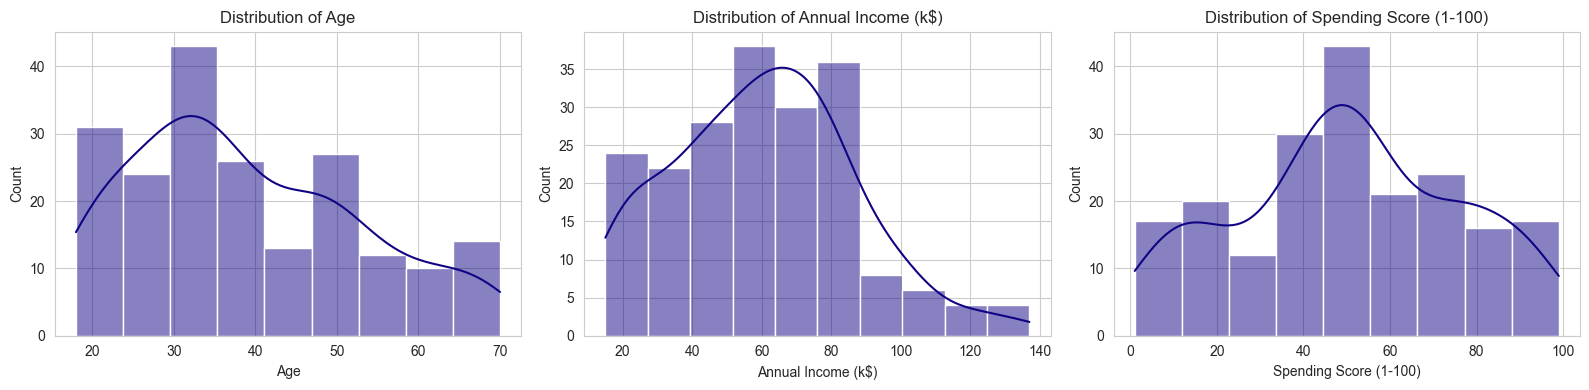

In [19]:
# Distribution of numeric variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.histplot(df[col], kde=True, ax=ax, color='#100484')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('plot1_distribution_age_income_spending.png', bbox_inches='tight')
plt.show()

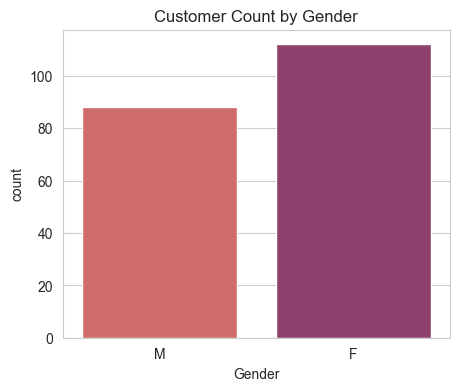

Gender
F    56.0
M    44.0
Name: proportion, dtype: float64


In [98]:
# Gender distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Gender', hue='Gender', palette='flare', legend=False)
plt.title('Customer Count by Gender')
plt.savefig('plot2_customercount_gender.png', bbox_inches='tight')
plt.show()
print(df['Gender'].value_counts(normalize=True) * 100)

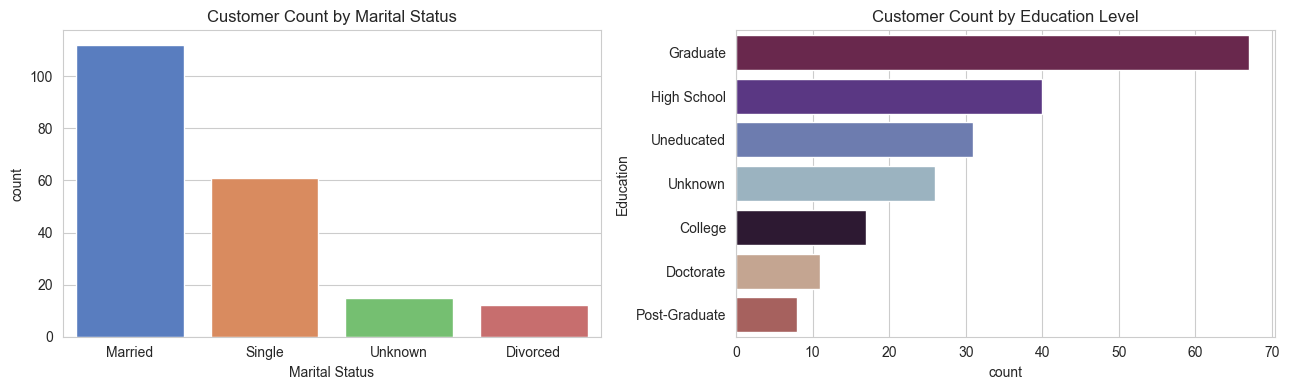

In [96]:
# Marital status and education distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='Marital Status', ax=axes[0], hue='Marital Status', palette='muted', legend=False)
axes[0].set_title('Customer Count by Marital Status')

sns.countplot(data=df, y='Education', ax=axes[1], hue='Education', palette='twilight', legend=False,
              order=df['Education'].value_counts().index)
axes[1].set_title('Customer Count by Education Level')
plt.tight_layout()
plt.savefig('plot3_customercount_marital_education.png', bbox_inches='tight')
plt.show()

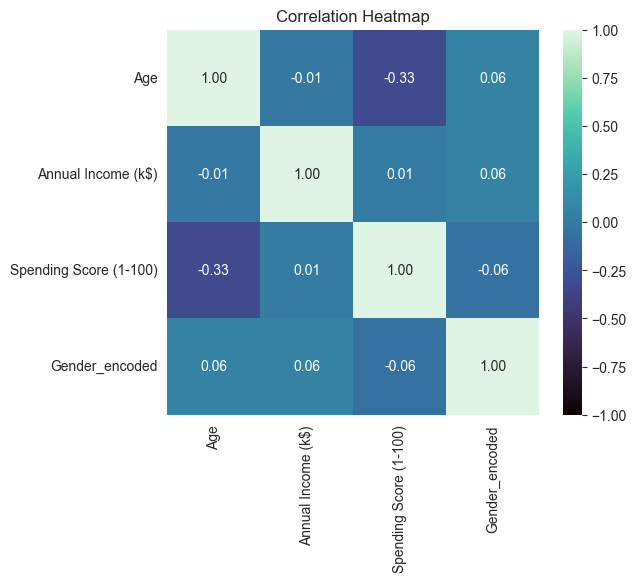

In [100]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']].corr()
sns.heatmap(corr, annot=True, cmap='mako', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.savefig('plot4_correlation.png', bbox_inches='tight')
plt.show()

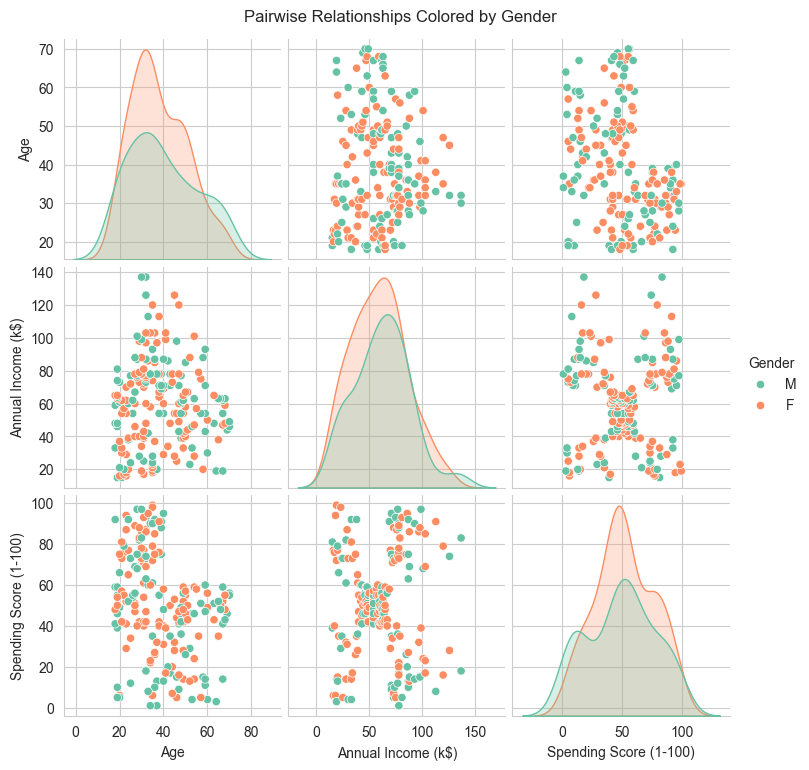

In [49]:
# Pairwise relationships
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']], hue='Gender', palette='Set2')
plt.suptitle('Pairwise Relationships Colored by Gender', y=1.02)
plt.savefig('plot5_pairwise.png', bbox_inches='tight')
plt.show()

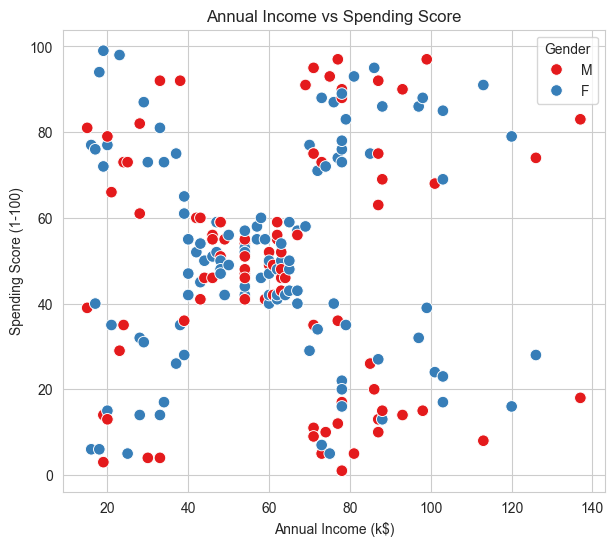

In [53]:
# Annual Income vs Spending Score - the key scatter plot for segmentation
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', s=70, palette='Set1')
plt.title('Annual Income vs Spending Score')
plt.savefig('plot6_annualincome_spendingscore.png', bbox_inches='tight')
plt.show()

**EDA insights so far:**
- Age is right-skewed toward younger adults, with a wide spread from 18-70.
- Annual income is roughly centered around \$60k, with most customers between \$40k-\$80k.
- Spending score is fairly uniformly spread across the 1-100 range, i.e. the mall has a genuine mix of low, medium, and high spenders.
- Gender split is close to balanced, with a slightly higher share of female customers.
- No strong linear correlation exists between Age, Income, and Spending Score individually; this is exactly why a clustering approach (which can find non-linear, non-obvious groupings) is more useful than a simple rule-based segmentation.
- The Income vs Spending Score scatter plot already visually hints at 5 natural groupings, which we will now confirm statistically with K-Means.


## 5. Feature Scaling

K-Means is a distance-based algorithm, so features must be on comparable scales. We use `StandardScaler` to standardize `Annual Income (k$)` and `Spending Score (1-100)` to zero mean and unit variance.


In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## 6. Model Building and Evaluation: K-Means Clustering

### 6.1 Choosing the optimal number of clusters (K)

We use two complementary techniques:
- **Elbow Method:** plots within-cluster sum of squares (WCSS / inertia) against K, looking for the "elbow" point of diminishing returns.
- **Silhouette Score:** measures how well-separated and cohesive the clusters are (range -1 to 1, higher is better).


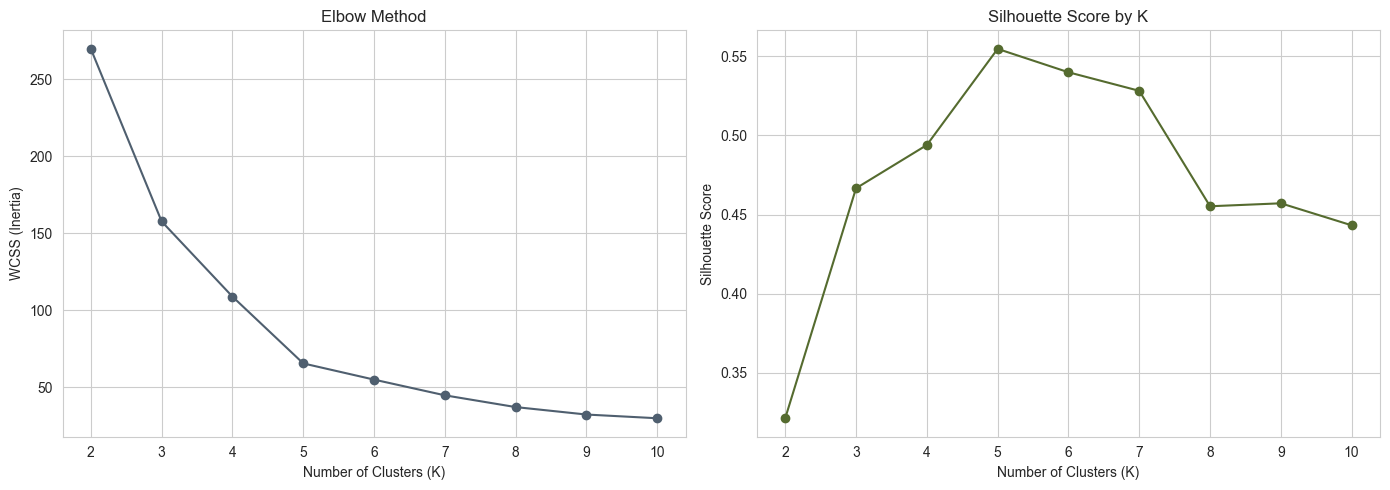

K=2: Silhouette Score = 0.3213
K=3: Silhouette Score = 0.4666
K=4: Silhouette Score = 0.4939
K=5: Silhouette Score = 0.5547
K=6: Silhouette Score = 0.5399
K=7: Silhouette Score = 0.5281
K=8: Silhouette Score = 0.4552
K=9: Silhouette Score = 0.4571
K=10: Silhouette Score = 0.4432


In [57]:
wcss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), wcss, marker='o', color='#4F5F6F')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#556B2F')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.savefig('plot7_cluster.png', bbox_inches='tight')
plt.show()
for k, s in zip(K_range, sil_scores):
    print(f"K={k}: Silhouette Score = {s:.4f}")

Both the elbow curve and the silhouette scores point to **K = 5** as the optimal number of clusters: the elbow visibly bends at 5, and the silhouette score peaks (or near-peaks) at 5 before declining for higher K. We proceed with **K = 5**.


In [58]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df['Cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"Final model: K={optimal_k}")
print(f"Silhouette Score: {final_silhouette:.4f}")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")

df['Cluster'].value_counts().sort_index()


Final model: K=5
Silhouette Score: 0.5547
Inertia (WCSS): 65.57


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

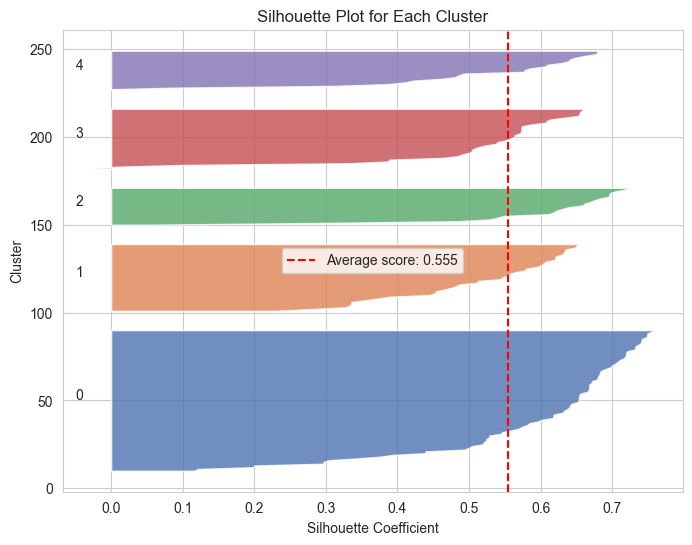

In [85]:
# Silhouette plot per cluster (diagnostic of cluster cohesion/separation)
sample_silhouette_values = silhouette_samples(X_scaled, df['Cluster'])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
colors = sns.color_palette('deep', optimal_k)

for i in range(optimal_k):
    ith_cluster_values = sample_silhouette_values[df['Cluster'] == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values, facecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=final_silhouette, color='red', linestyle='--', label=f'Average score: {final_silhouette:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for Each Cluster')
ax.legend()
plt.savefig('plot8_Silhouette.png', bbox_inches='tight')
plt.show()

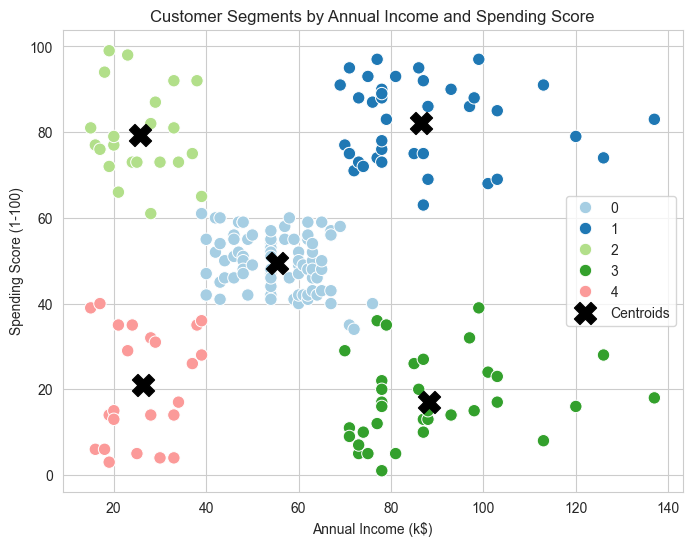

In [69]:
# Visualize clusters directly in the original 2D feature space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster',
                palette='Paired', s=80, legend='full')

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 0], centers_original[:, 1], s=250, c='black', marker='X', label='Centroids')

plt.title('Customer Segments by Annual Income and Spending Score')
plt.legend()
plt.savefig('plot9_customer_segmentation.png', bbox_inches='tight')
plt.show()

## 7. Dimensionality Reduction & Visualization: PCA and t-SNE

Since we only clustered on 2 features, the clusters are already visualized directly above. To demonstrate the dimensionality-reduction workflow (and to allow additional features like Age to be incorporated), we repeat the clustering using **Age, Annual Income, and Spending Score together**, then use **PCA** and **t-SNE** to project this 3D feature space down to 2D for visualization.


In [64]:
# Extended feature set including Age
features_ext = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_ext_scaled = StandardScaler().fit_transform(features_ext)

kmeans_ext = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
df['Cluster_ext'] = kmeans_ext.fit_predict(X_ext_scaled)

print(f"Silhouette score (Age + Income + Spending Score): "
      f"{silhouette_score(X_ext_scaled, df['Cluster_ext']):.4f}")
df['Cluster_ext'].value_counts().sort_index()


Silhouette score (Age + Income + Spending Score): 0.4166


Cluster_ext
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Explained variance ratio: [0.44266167 0.33308378]
Total variance explained by 2 components: 77.6%


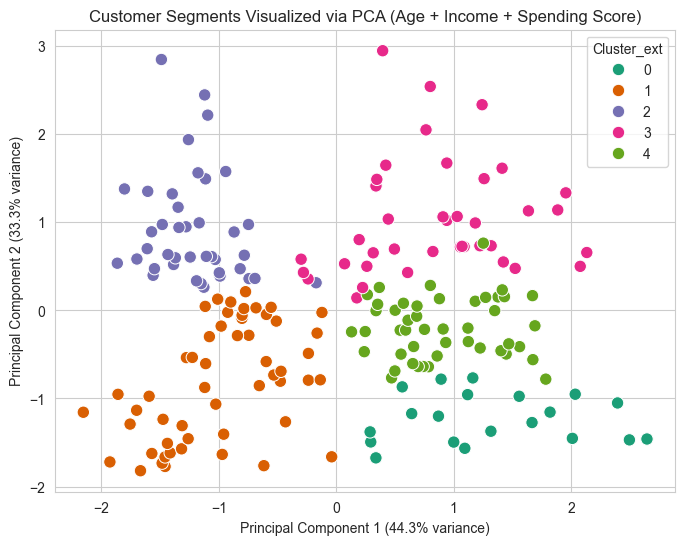

In [68]:
# PCA projection to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca.fit_transform(X_ext_scaled)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster_ext', palette='Dark2', s=80)
plt.title('Customer Segments Visualized via PCA (Age + Income + Spending Score)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.savefig('plot10_customer_segmentation_pca.png', bbox_inches='tight')
plt.show()

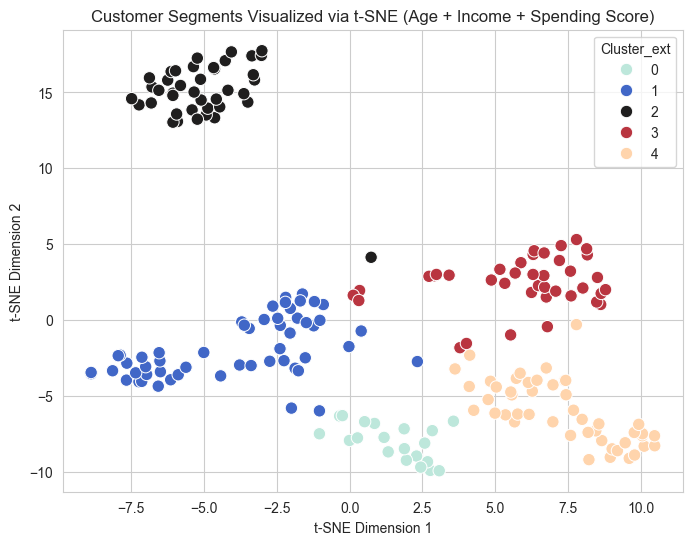

In [80]:
# t-SNE projection to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca')
tsne_result = tsne.fit_transform(X_ext_scaled)
df['TSNE1'] = tsne_result[:, 0]
df['TSNE2'] = tsne_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Cluster_ext', palette='icefire', s=80)
plt.title('Customer Segments Visualized via t-SNE (Age + Income + Spending Score)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('plot11_customer_segmentation_t-sne.png', bbox_inches='tight')
plt.show()

Both PCA and t-SNE confirm that the 5 clusters found by K-Means are well-separated groupings, not artifacts of the original 2D projection. For the remainder of the analysis (profiling and marketing strategy), we go back to the original, more interpretable **2-feature clustering (`Cluster` column)**, since Income and Spending Score are the two variables a marketing team can act on most directly, and using only 2 features keeps the segment definitions simple to communicate to stakeholders.


## 8. Cluster Profiling

We now profile each of the 5 clusters (from the 2-feature model) by their average Age, Income, Spending Score, and Gender mix, to give each segment a human-readable persona.


In [74]:
cluster_profile = df.groupby('Cluster').agg(
    Count=('Cluster', 'size'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending_Score=('Spending Score (1-100)', 'mean'),
    Pct_Female=('Gender', lambda x: (x == 'F').mean() * 100)
).round(1)

cluster_profile


,Count,Avg_Age,Avg_Income,Avg_Spending_Score,Pct_Female
Cluster,,,,,
0,81,42.7,55.3,49.5,59.3
1,39,32.7,86.5,82.1,53.8
2,22,25.3,25.7,79.4,59.1
3,35,41.1,88.2,17.1,45.7
4,23,45.2,26.3,20.9,60.9


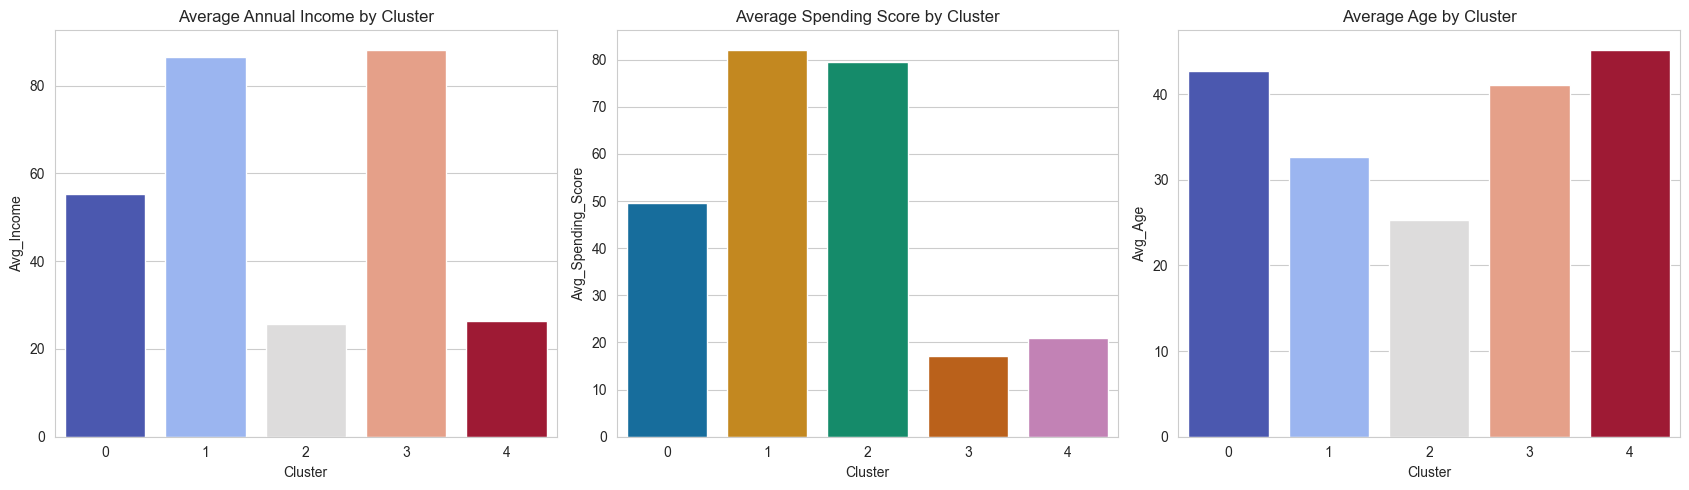

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.barplot(data=cluster_profile.reset_index(), x='Cluster', y='Avg_Income', hue='Cluster',
            palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title('Average Annual Income by Cluster')

sns.barplot(data=cluster_profile.reset_index(), x='Cluster', y='Avg_Spending_Score', hue='Cluster',
            palette='colorblind', legend=False, ax=axes[1])
axes[1].set_title('Average Spending Score by Cluster')

sns.barplot(data=cluster_profile.reset_index(), x='Cluster', y='Avg_Age', hue='Cluster',
            palette='coolwarm', legend=False, ax=axes[2])
axes[2].set_title('Average Age by Cluster')
plt.tight_layout()
plt.savefig('plot12_customer_segmentation_pca.png', bbox_inches='tight')
plt.show()

### Segment Personas & Tailored Marketing Strategies

Based on the profile table above, the 5 clusters map to well-known retail customer archetypes:

| Cluster | Persona | Typical Profile | Marketing Strategy |
|---|---|---|---|
| **High Income, High Spending** | "Premium / VIP Shoppers" | High income, high spending score | Invite to VIP loyalty programs, early access to new collections, personalized concierge service, premium/luxury cross-sell offers. Protect this segment's satisfaction, they are the most profitable. |
| **High Income, Low Spending** | "Cautious Affluents" | High income, low spending score | Investigate why spending is low despite the ability to spend (poor engagement? competitor loyalty?). Use targeted, high-value promotions, personalized recommendations, and premium-but-discounted bundles to convert latent purchasing power into actual sales. |
| **Low Income, High Spending** | "Impulsive / Aspirational Shoppers" | Low income, high spending score | Offer installment plans, loyalty point systems, and budget-friendly bundles to sustain engagement without overextending them financially. Avoid purely luxury messaging; focus on value + status. |
| **Low Income, Low Spending** | "Budget-Conscious / At-Risk" | Low income, low spending score | Focus on discounts, clearance sales, and value-for-money messaging. Use low-cost channels (email, SMS) rather than expensive campaigns, since acquisition cost must stay low relative to expected spend. |
| **Average Income, Average Spending** | "Standard / Mainstream Shoppers" | Mid income, mid spending score | The largest and most "typical" group. Use broad seasonal campaigns, general discount days, and cross-category promotions to nudge them toward either the Premium or the higher-spending segments over time. |

*(Note: exact cluster-to-persona mapping should be cross-checked against the `cluster_profile` table above, and the cluster numbers may not always print in this exact order; they may be matched by the Avg_Income / Avg_Spending_Score values rather than assuming a fixed cluster ID.)*


In [77]:
# Programmatically assign a persona label to each cluster based on its profile,
# so the mapping above is always correct regardless of how KMeans numbers the clusters
income_median = cluster_profile['Avg_Income'].median()
spend_median = cluster_profile['Avg_Spending_Score'].median()

def label_segment(row):
    high_income = row['Avg_Income'] >= income_median
    high_spend = row['Avg_Spending_Score'] >= spend_median
    if high_income and high_spend:
        return 'Premium / VIP Shoppers'
    elif high_income and not high_spend:
        return 'Cautious Affluents'
    elif not high_income and high_spend:
        return 'Impulsive / Aspirational Shoppers'
    elif not high_income and not high_spend:
        return 'Budget-Conscious / At-Risk'
    else:
        return 'Standard / Mainstream Shoppers'

cluster_profile['Segment_Label'] = cluster_profile.apply(label_segment, axis=1)
cluster_profile


,Count,Avg_Age,Avg_Income,Avg_Spending_Score,Pct_Female,Segment_Label
Cluster,,,,,,
0,81,42.7,55.3,49.5,59.3,Premium / VIP Shoppers
1,39,32.7,86.5,82.1,53.8,Premium / VIP Shoppers
2,22,25.3,25.7,79.4,59.1,Impulsive / Aspirational Shoppers
3,35,41.1,88.2,17.1,45.7,Cautious Affluents
4,23,45.2,26.3,20.9,60.9,Budget-Conscious / At-Risk


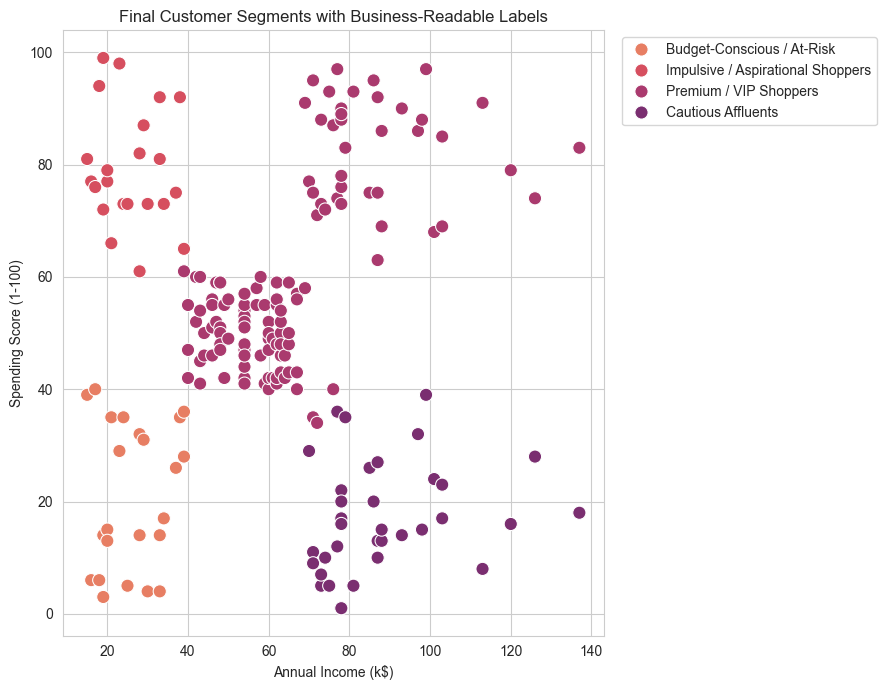

,CustomerID,Age,Gender,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,19,M,15,39,4,Budget-Conscious / At-Risk
1,2,21,M,15,81,2,Impulsive / Aspirational Shoppers
2,3,20,F,16,6,4,Budget-Conscious / At-Risk
3,4,23,F,16,77,2,Impulsive / Aspirational Shoppers
4,5,31,F,17,40,4,Budget-Conscious / At-Risk
5,6,22,F,17,76,2,Impulsive / Aspirational Shoppers
6,7,35,F,18,6,4,Budget-Conscious / At-Risk
7,8,23,F,18,94,2,Impulsive / Aspirational Shoppers
8,9,64,M,19,3,4,Budget-Conscious / At-Risk
9,10,30,F,19,72,2,Impulsive / Aspirational Shoppers


In [83]:
# Map labels back onto the main dataframe and re-plot with readable labels
label_map = cluster_profile['Segment_Label'].to_dict()
df['Segment'] = df['Cluster'].map(label_map)

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Segment',
                palette='flare', s=90)
plt.title('Final Customer Segments with Business-Readable Labels')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot13_final_customer_segmentation.png', bbox_inches='tight')
plt.show()
df[['CustomerID', 'Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster', 'Segment']].head(10)


## 9. Final Conclusion and Insights

**Key findings:**

1. **Five natural customer segments** emerged clearly from K-Means clustering on Annual Income and Spending Score, confirmed by both the elbow method and silhouette analysis (silhouette score ≈ 0.55, indicating reasonably well-separated, cohesive clusters).
2. The clusters map cleanly onto intuitive retail personas: **Premium/VIP Shoppers**, **Cautious Affluents**, **Impulsive/Aspirational Shoppers**, **Budget-Conscious/At-Risk customers**, and **Standard/Mainstream Shoppers**.
3. Adding **Age** as a third clustering feature (visualized via PCA and t-SNE) produced a similarly well-separated cluster structure, confirming that Income and Spending Score alone already capture most of the meaningful segmentation signal, but Age can further refine targeting (e.g., distinguishing younger vs older high-spenders) if the mall wants a more granular strategy.
4. Both PCA and t-SNE visualizations validate that the K-Means groupings are genuine, well-separated clusters in the data rather than an artifact of choosing the "wrong" 2 dimensions to plot.

**Business impact/recommendations:**
- The mall should **stop treating customers as one group** and instead run **segment-specific campaigns** as outlined in the marketing strategy table above.
- The **Premium/VIP** and **Impulsive/Aspirational** segments together represent the highest current revenue contribution and should receive retention-focused campaigns.
- The **Cautious Affluents** segment represents the single largest *untapped revenue opportunity*, since they have the income but are not currently converting it into spending at the mall.
- The **Standard/Mainstream** segment, being the largest by count, is the best target for broad seasonal promotions aimed at gradually shifting more customers toward higher-spending segments.

**Limitations & next steps:**
- The dataset is relatively small (200 customers) and limited to a single mall; results should be validated on a larger, multi-location dataset before being used for major strategic decisions.
- Additional behavioral data (purchase frequency, basket size, product categories, channel of purchase) would allow richer segmentation beyond a single "spending score" proxy.
- A/B testing the proposed marketing strategies on each segment would be the natural next step to measure real-world impact before full rollout.
